## Spatio-Temporal Study of Hydro-Climatic Variability and Thermal Intensity in Ethiopia (2000 - 2025)

In [111]:
import os
import ee
import geemap
import numpy as np
import panel as pn
import folium
import branca 
import warnings
import hvplot.pandas 
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from bokeh.resources import INLINE
from IPython.display import HTML
from branca.element import MacroElement, Template
from matplotlib.patches import FancyArrowPatch

## Introduction 
**Context and Problem**

Ethiopia’s reliance on rain-fed agriculture makes the country highly exposed to climate variability, because more than 80% of the population depends on subsistence farming. Although drought research has often focused on rainfall deficits (Funk et al., 2015), climatic change shows that heat extremes can also intensify agricultural vulnerability (Gleixner et al., 2016). This study examines whether Ethiopia’s highland farming zones, historically benefited from cooler conditions than the lowlands, are becoming more exposed to agricultural drought.

Rising temperatures increase Vapor Pressure Deficit, a measure of the atmosphere’s demand for moisture. Higher atmospheric demand can accelerate water loss from soils and vegetation, even when rainfall totals appear close to average. For this reason, drought risk cannot be assessed through precipitation alone. In this project, agricultural drought is understood as a combined condition of rainfall shortage, soil moisture decline, vegetation stress, and heat exposure (Kogan, 1995). These pressures have wider implications for rural livelihoods, mobility, and climate-related displacement (Philip et al., 2022).

Using 26 years of climate and vegetation data, this project identifies district-level drought hotspots across Ethiopia. The analysis combines rainfall, temperature, soil moisture, and the Drought Stress Index to compare risk across agro-ecological zones and through time. Attention is given to areas where heat and moisture stress overlap, including the Rift Valley and neighbouring highland districts (Haile et al., 2019). Through interactive maps and time-series visualisation, the study supports proactive assessment of drought exposure and highlights where targeted adaptation may be most urgent (Vicente-Serrano et al., 2010; Abatzoglou et al., 2018).

## Data Sources Presentation
Raster data for this project were processed in Google Earth Engine (GEE), allowing large climate datasets to be extracted consistently across Ethiopia. The main climate source was the ECMWF ERA5-Land Monthly Aggregated dataset, selected because it provides long-term land surface variables at approximately 9 km spatial resolution (Muñoz-Sabater et al., 2021). These data derived rainfall, temperature, and soil moisture indicators for 2000 - 2025.

To convert gridded climate data into district-level values, the GEE reduceRegions function was applied to Ethiopia’s ADM_2 administrative boundaries. This produced zonal statistics for each district, allowing raster pixels to be summarised into policy-relevant spatial units. ADM_2 was chosen because district-level analysis supports local comparison of drought exposure and identifies areas where adaptation support may be needed.

The workflow focused on indicators linked to agricultural drought, including precipitation, temperature, soil moisture, land surface temperature, and vegetation condition. Monthly values were aggregated and joined into a master district-level dataset so patterns could be compared through time. Duplicate administrative names and geometry mismatches were checked during merging to ensure consistent district coverage.

Missing values were handled using spatio-temporal mean imputation, where gaps were filled with suitable monthly averages. This maintained complete spatial coverage for the dashboard while avoiding removal of districts with partial data gaps. The final dataset provided a stable foundation for interactive mapping, time-series visualisation, and comparison of heat and moisture stress across Ethiopian districts for local decision-making.

In [112]:
#initialize google earth engine
try:
    ee.Initialize(project='********************')
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project='********************')

In [113]:
#load the asset directly from GEE
asset_path = "projects/********************/assets/ethiopia_districts"
ee_districts = ee.FeatureCollection(asset_path)

In [114]:
#define the ERA5-Land monthly collection
#pick key vars - smaller data size
era5_land = ee.ImageCollection("ECMWF/ERA5_LAND/MONTHLY_AGGR") \
    .filterDate('2000-01-01', '2025-12-31') \
    .select([
        'temperature_2m', 
        'total_precipitation_sum', 
        'volumetric_soil_water_layer_2'
    ])
#define zonal statistics
def calculate_zonal_stats(image):
    #extract timestamp
    date_str = image.date().format('YYYY-MM-dd')
    
    #reduce regions: mean of selected bands per district
    #scale 11132 matches native ~9km res. of ERA5-Land
    stats = image.reduceRegions(
        collection=ee_districts,
        reducer=ee.Reducer.mean(),
        scale=11132
    )
    
    # Attach the date to each feature (district)
    return stats.map(lambda f: f.set('date', date_str))

#run cloud computation
print("Requesting 26 years of district-level averages from Google Earth Engine")
#flatten collection - simple list of rows
monthly_stats = era5_land.map(calculate_zonal_stats).flatten()

#convert to df (fixed: ee_to_df)
print("Downloading results to local environment")
df_results = geemap.ee_to_df(monthly_stats)

#post processing + save as local geopackage
if not df_results.empty:
    print(f"Extraction successful! Records retrieved: {len(df_results)}")
    
    df_results['date'] = pd.to_datetime(df_results['date'])
    df_results['year'] = df_results['date'].dt.year
    df_results['month'] = df_results['date'].dt.month
    
    #load local shapefile to merge with data
    local_shp = r"C:\Users\FlawiyaShirishMore\Downloads\Dashboard\.shp\ethiopia_districts.shp"
    gdf_local = gpd.read_file(local_shp)
    
    final_master_gdf = gdf_local.merge(df_results, on='NAME_2')
    
    output_name = "ethiopia_monthly_master_2000_2025.gpkg"
    final_master_gdf.to_file(output_name, driver="GPKG")
    print(f"FINAL MASTER FILE SAVED: {output_name}")
else:
    print("Error: No data retrieved. Please check the Asset permissions.")

Requesting 26 years of district-level averages from Google Earth Engine
Extraction successful! Records retrieved: 24648
FINAL MASTER FILE SAVED: ethiopia_monthly_master_2000_2025.gpkg


In [115]:
# load data
csv_path = r"C:\Users\FlawiyaShirishMore\Downloads\Dashboard\Data\ethiopia_monthly_master_2000_2025.csv"
shp_path = r"C:\Users\FlawiyaShirishMore\Downloads\Dashboard\.shp\ethiopia_districts.shp"

In [116]:
df_raw = pd.read_csv(csv_path)
gdf_districts = gpd.read_file(shp_path).to_crs(epsg=4326)

In [117]:
#cleaning of data
df_raw['date'] = pd.to_datetime(df_raw['date'])
df_raw['year'] = df_raw['date'].dt.year
df_raw['temp_c'] = df_raw['temperature_2m'] - 273.15
df_raw['precip_mm'] = df_raw['total_precipitation_sum'] * 1000
all_districts = gdf_districts['NAME_2'].unique()
all_dates = df_raw['date'].unique()
skeleton = pd.MultiIndex.from_product([all_districts, all_dates], names=['NAME_2', 'date']).to_frame(index=False)

In [118]:
#merge data
df_clean = skeleton.merge(df_raw, left_on=['NAME_2', 'date'], right_on=['feature_id', 'date'], how='left')

In [119]:
#calculating drought stress
for col in ['temp_c', 'volumetric_soil_water_layer_2']:
    low, high = df_clean[col].quantile([0.01, 0.99])
    df_clean[f'{col}_n'] = ((df_clean[col] - low) / (high - low)).clip(0, 1)
df_clean['drought_stress'] = (df_clean['temp_c_n'] + (1 - df_clean['volumetric_soil_water_layer_2_n'])) / 2

In [120]:
#Spatio-Temporal Imputation
# Find the average for every date across the whole country
national_monthly_means = df_clean.groupby('date')[['temp_c', 'precip_mm', 'drought_stress']].transform('mean')

In [121]:
#filling NaN values with national avg to have full data
df_clean['temp_c'] = df_clean['temp_c'].fillna(national_monthly_means['temp_c'])
df_clean['precip_mm'] = df_clean['precip_mm'].fillna(national_monthly_means['precip_mm'])
df_clean['drought_stress'] = df_clean['drought_stress'].fillna(national_monthly_means['drought_stress'])

In [122]:
# Ensure 'year' is present for the filled rows
df_clean['year'] = df_clean['date'].dt.year

In [123]:
#base_shapes should come directly from the shapefile to ensure 100% spatial integrity
base_shapes = gdf_districts[['NAME_2', 'geometry']].dissolve(by='NAME_2').reset_index()

In [124]:
#prep temp data for baseline yr (2000)
temp_2000 = df_clean[df_clean['year'] == 2000].groupby('NAME_2')['temp_c'].mean().reset_index()
#calc national avg for 2000 (gap fill)
nat_temp_avg_2000 = temp_2000['temp_c'].mean()
#master join
map1_gdf = gdf_districts.copy()
map1_gdf = map1_gdf.merge(temp_2000, on='NAME_2', how='left')
#fix: fill gaps (e.g. North Shewa) with national mean for that yr
map1_gdf['temp_c'] = map1_gdf['temp_c'].fillna(nat_temp_avg_2000)

## Geovisualisation and Analysis Rationale
The geovisualisation is designed to show how drought risk develops from climate drivers into observable environmental stress. The main analytical measure is the Drought Stress Index (DSI), adapted from the logic of Kogan’s Temperature Condition Index (TCI), where vegetation stress is assessed in relation to thermal conditions (Kogan, 1995). In this project, DSI combines normalised temperature (T) and soil moisture (SM) to represent locations where high heat demand coincides with limited water availability across districts nationally.

$$
\text{DSI} = \frac{ \left( T_{\text{norm}} + (1 - SM_{\text{norm}}) \right) }{2}
$$

By combining these variables, the dashboard moves beyond descriptive mapping and supports diagnostic analysis. The static introductory maps provide spatial context by showing Ethiopia’s regional setting, baseline temperature patterns, and initial evidence of warming related exposure. The interactive dashboard then allows users to explore how drought stress changes across districts and through time.

A key part of the analysis is the classification of districts into climatic zones. This makes it possible to compare whether historically cooler highland areas are shifting closer to high-risk drought conditions, while also identifying districts where heat and moisture stress overlap most strongly (Haile et al., 2019). The approach therefore links spatial mapping, time-series exploration, and zone-based comparison. Together, these elements provide a clearer assessment of agricultural drought risk across Ethiopia’s administrative landscape.

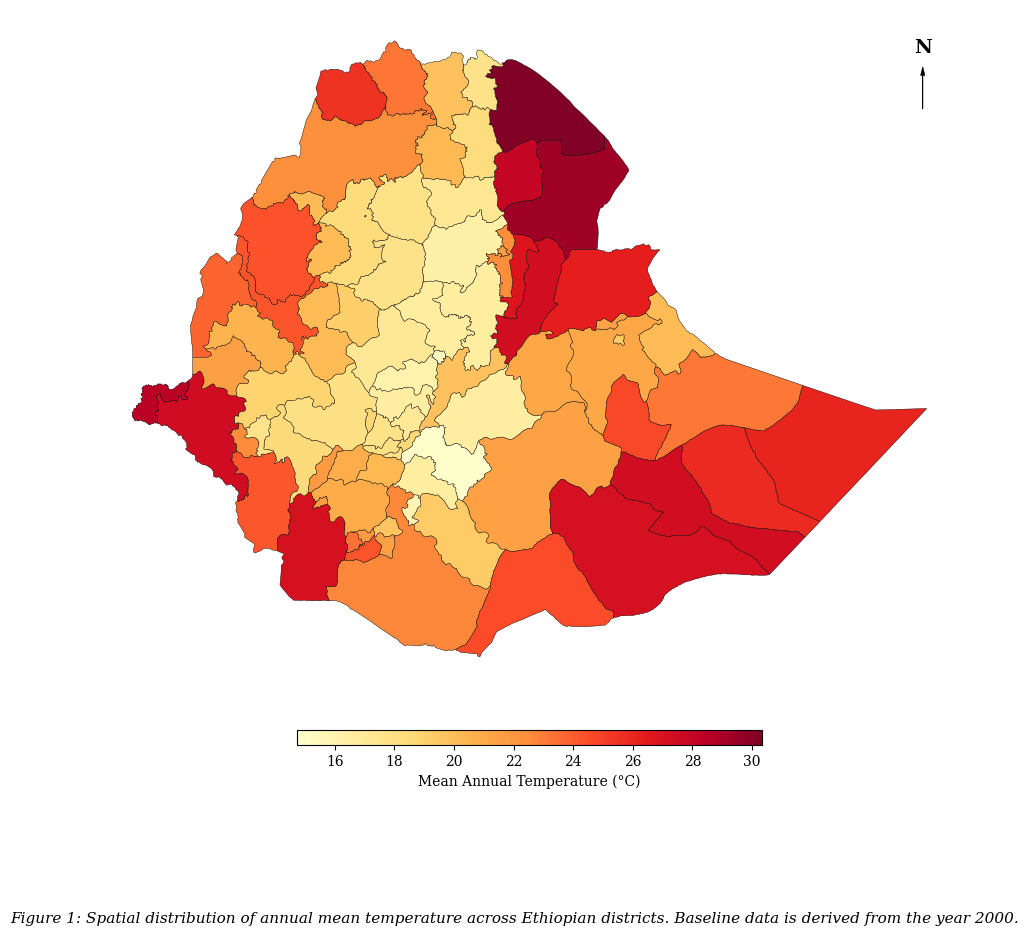

In [125]:
plt.rcParams['font.family'] = 'serif'

fig, ax = plt.subplots(figsize=(12, 11))

map1_gdf.plot(
    column='temp_c', 
    cmap='YlOrRd',
    legend=True, 
    edgecolor='black', 
    linewidth=0.3, 
    ax=ax,
    legend_kwds={
        'label': "Mean Annual Temperature (°C)", 
        'orientation': "horizontal", 
        'pad': 0.05,
        'shrink': 0.5,
        'aspect': 30 
    }
)

ax.axis('off')

x, y, arrow_length = 0.95, 0.85, 0.07
ax.annotate('N', xy=(x, y + arrow_length + 0.01), xycoords='axes fraction', 
            fontsize=14, fontweight='bold', ha='center', va='bottom')
arrow = patches.FancyArrowPatch(
    (x, y), (x, y + arrow_length), 
    transform=ax.transAxes,
    arrowstyle='Simple, tail_width=0.1, head_width=3, head_length=6',
    color='black', lw=0.5
)
ax.add_patch(arrow)

caption_text = (
    f"Figure 1: Spatial distribution of annual mean temperature across Ethiopian districts. "
    f"Baseline data is derived from the year 2000."
)
plt.figtext(0.5, 0.05, caption_text, ha='center', fontsize=11, 
            style='italic', wrap=True)

plt.savefig('map_1_temperature_final.png', dpi=300, bbox_inches='tight')
plt.show()

In [126]:
#check avg temp for whole country per yr
yearly_trend = df_clean.groupby('year')['temp_c'].mean()
print("Yearly Average Temperature (National)")
print(yearly_trend)

Yearly Average Temperature (National)
year
2000    21.228532
2001    21.132081
2002    21.594945
2003    21.557304
2004    21.434639
2005    21.611073
2006    21.380249
2007    21.456292
2008    21.406977
2009    22.061673
2010    21.538486
2011    21.565662
2012    21.649559
2013    21.409609
2014    21.425164
2015    22.052545
2016    22.002587
2017    21.856264
2018    21.466945
2019    21.837736
2020    21.594574
2021    21.816109
2022    21.914509
2023    22.000868
2024    22.328542
2025    22.079576
Name: temp_c, dtype: float64


In [127]:
#prep precip data for 2020
#use 'precip_mm' (m * 1000, calc earlier)
precip_2020 = df_clean[df_clean['year'] == 2020].groupby('NAME_2')['precip_mm'].mean().reset_index()
#calc national avg for gap fill
nat_precip_avg = precip_2020['precip_mm'].mean()
#master join
map2_gdf = gdf_districts.copy()
map2_gdf = map2_gdf.merge(precip_2020, on='NAME_2', how='left')
#fill North Shewa gap with national avg
map2_gdf['precip_mm'] = map2_gdf['precip_mm'].fillna(nat_precip_avg)

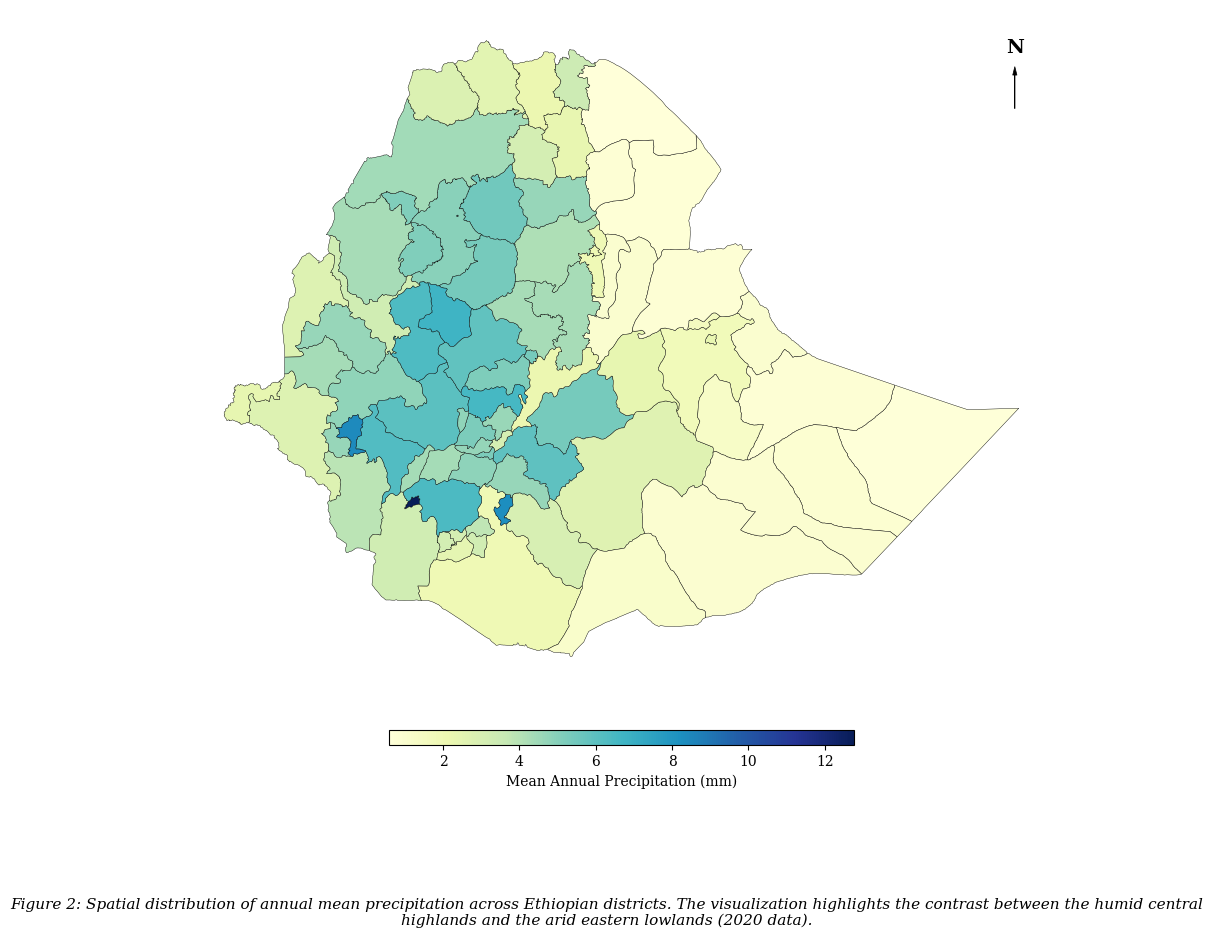

In [128]:
fig, ax = plt.subplots(figsize=(12, 11))

map2_gdf.plot(
    column='precip_mm', 
    cmap='YlGnBu', 
    legend=True, 
    edgecolor='black', 
    linewidth=0.3, # Matches Map 1
    ax=ax,
    legend_kwds={
        'label': "Mean Annual Precipitation (mm)", 
        'orientation': "horizontal", 
        'pad': 0.05, # Matches Map 1
        'shrink': 0.5, # Matches Map 1
        'aspect': 30 
    }
)

ax.axis('off')

x, y, arrow_length = 0.95, 0.85, 0.07
ax.annotate('N', xy=(x, y + arrow_length + 0.01), xycoords='axes fraction', 
            fontsize=14, fontweight='bold', ha='center', va='bottom')
arrow = patches.FancyArrowPatch(
    (x, y), (x, y + arrow_length), 
    transform=ax.transAxes,
    arrowstyle='Simple, tail_width=0.1, head_width=3, head_length=6',
    color='black', lw=0.5
)
ax.add_patch(arrow)

caption_text = (
    f"Figure 2: Spatial distribution of annual mean precipitation across Ethiopian districts. "
    f"The visualization highlights the contrast between the humid central highlands and the arid "
    f"eastern lowlands (2020 data)."
)
plt.figtext(0.5, 0.05, caption_text, ha='center', fontsize=11, 
            style='italic', wrap=True)

plt.savefig('map_2_precipitation_final.png', dpi=300, bbox_inches='tight')
plt.show()

In [129]:
#calc warming (2025 - 2000)
#group by NAME_2
temp_2000 = df_clean[df_clean['year'] == 2000].groupby('NAME_2')['temp_c'].mean()
temp_2025 = df_clean[df_clean['year'] == 2025].groupby('NAME_2')['temp_c'].mean()
#create anomaly df
anomaly = (temp_2025 - temp_2000).reset_index()
anomaly.columns = ['NAME_2', 'warming_val']
#calc national mean (filler)
national_mean = anomaly['warming_val'].mean()
#left join
final_static_gdf = gdf_districts.copy()
final_static_gdf = final_static_gdf.merge(anomaly, on='NAME_2', how='left')
#fill NaN warming values with the national average
final_static_gdf['warming_val'] = final_static_gdf['warming_val'].fillna(national_mean)

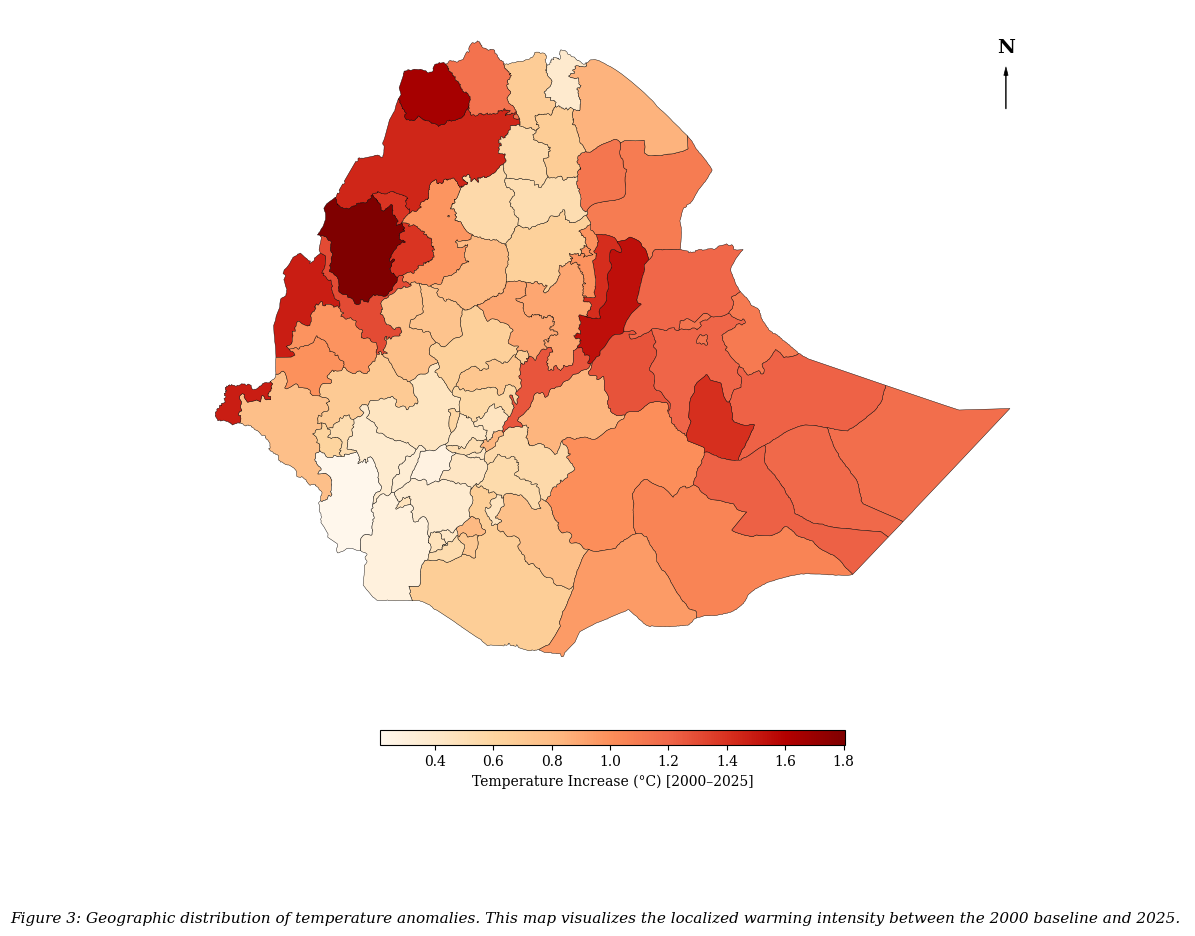

In [130]:
plt.rcParams['font.family'] = 'serif'

fig, ax = plt.subplots(figsize=(12, 11))

final_static_gdf.plot(
    column='warming_val', 
    cmap='OrRd', 
    legend=True, 
    edgecolor='black', 
    linewidth=0.3, 
    ax=ax,
    legend_kwds={
        'label': "Temperature Increase (°C) [2000–2025]", 
        'orientation': "horizontal", 
        'pad': 0.05,
        'shrink': 0.5,
        'aspect': 30 
    }
)

ax.axis('off')

x, y, arrow_length = 0.95, 0.85, 0.07
ax.annotate('N', xy=(x, y + arrow_length + 0.01), xycoords='axes fraction', 
            fontsize=14, fontweight='bold', ha='center', va='bottom')
arrow = patches.FancyArrowPatch(
    (x, y), (x, y + arrow_length), 
    transform=ax.transAxes,
    arrowstyle='Simple, tail_width=0.1, head_width=3, head_length=6',
    color='black', lw=0.5
)
ax.add_patch(arrow)

caption_text = (
    f"Figure 3: Geographic distribution of temperature anomalies. "
    f"This map visualizes the localized warming intensity between the 2000 baseline and 2025. "
)

plt.figtext(0.5, 0.05, caption_text, ha='center', fontsize=11, 
            style='italic', wrap=True)

# 5. Save and Show
plt.savefig('map_3_warming_intensity_final.png', dpi=300, bbox_inches='tight')
plt.show()

In [131]:
#calc water balance (input - output)
#potential evaporation is usually negative in ERA5 so we use P + PET
df_clean['water_balance'] = df_clean['precip_mm'] + (df_clean['potential_evaporation_sum'] * 1000)
#bottom 10% soil moisture = drought months
threshold = df_clean['volumetric_soil_water_layer_2'].quantile(0.10)
df_clean['is_drought'] = df_clean['volumetric_soil_water_layer_2'] < threshold
#calc chronic vulnerability score
vulnerability_scores = df_clean.groupby('NAME_2')['is_drought'].sum().reset_index()
vulnerability_scores.columns = ['NAME_2', 'chronic_count']
df_clean = df_clean.merge(vulnerability_scores, on='NAME_2')
#create zone classes for plots
#arid vs humid (based on median precip)
median_precip = df_clean.groupby('NAME_2')['precip_mm'].median()
df_clean['zone'] = df_clean['NAME_2'].map(
    lambda x: 'Arid' if median_precip.get(x, 0) < median_precip.median() else 'Humid'
)

## Interactivity and design choices
The dashboard uses Panel to create an interactive web-based environment for exploring drought indicators (HoloViz, 2023). Folium provides the spatial component, allowing district-level choropleth maps to be rendered from the joined shapefile and climate dataset. To improve performance, district geometries are simplified by 0.01 degrees, and each map is displayed as an HTML object so updates redraw cleanly when the selected year or metric changes.

Interactivity is controlled through a temporal slider and metric selector, enabling users to examine 26 years of variation across rainfall, temperature, soil moisture, NDVI, and the Drought Stress Index. Branca continuous colour maps create smooth gradients, reducing visual bias when values are grouped into fixed classes (Harrower and Brewer, 2003). The colour design is kept simple, with blues for rainfall and oranges or reds for heat-related variables, so the meaning of each layer remains clear.

The map is linked with three statistical views: a bar chart for hotspot districts, a scatter plot comparing climate drivers, and a violin plot showing differences between climatic zones. This layout combines spatial and statistical evidence in one view, supporting interpretation and verification through the accompanying demonstration video online. [https://youtu.be/xb6IczbJnDM].

In [132]:
warnings.filterwarnings('ignore')

pn.extension(design='material')
base_shapes_final = base_shapes.copy()
invalid = base_shapes_final[~base_shapes_final.geometry.is_valid]

base_shapes_final['geometry'] = base_shapes_final['geometry'].simplify(0.01, preserve_topology=True)

df_annual = df_clean.groupby(['year', 'NAME_2']).agg({
    'temp_c': 'max', 'precip_mm': 'sum', 'drought_stress': 'max', 'zone': 'first'                  
}).reset_index().round(2)
df_annual.to_csv('dashboard_data_preview.csv', index=False)

label_map = {
    'temp_c': 'Maximum Temperature (°C)',
    'precip_mm': 'Total Precipitation (mm)',
    'drought_stress': 'Peak Drought Stress Index'
}

EXTREME_CMAP = ['#d35400', '#008080'] 

year_slider = pn.widgets.IntSlider(name='Select Year', start=2000, end=2025, value=2021, width=300,
    styles={'color': '#2c3e50'}, stylesheets=[':host { color: #2c3e50; --design-primary-color: #2980b9; }'])
variable_select = pn.widgets.Select(name='Climate Metric', options=label_map, width=300,
    styles={'color': '#2c3e50'}, stylesheets=[':host { color: #2c3e50 !important; } :host label { color: #2c3e50 !important; } :host .bk-input { color: #2c3e50 !important; }'])

@pn.depends(year_slider.param.value, variable_select.param.value)
def get_map_pane(year, var_label):

    var = [k for k, v in label_map.items() if v == var_label][0]
    year_df = df_annual[df_annual['year'] == year].copy()
    map_gdf = base_shapes_final.merge(year_df, on='NAME_2', how='left')
    m = folium.Map(location=[9.1, 40.5], zoom_start=6, tiles='cartodbpositron')
    m.fit_bounds([[3.4, 33.0], [14.9, 48.0]])
    
    vmin, vmax = map_gdf[var].min(), map_gdf[var].max()
    if vmin == vmax:
        vmin -= 1
        vmax += 1
    cmap = (branca.colormap.linear.Spectral_11 if var == 'precip_mm' 
            else branca.colormap.linear.OrRd_09).scale(vmin, vmax)
    cmap.caption = f"{var_label}"

    map_gdf[var] = map_gdf[var].fillna(map_gdf[var].mean())
    map_gdf['geometry'] = map_gdf['geometry'].buffer(0)

    folium.GeoJson(
        map_gdf,
        style_function=lambda f, var=var, cmap=cmap, vmin=vmin, vmax=vmax: {
            'fillColor': cmap(f['properties'][var]) if f['properties'][var] is not None else '#ffffff',
            'color': '#34495e', 'weight': 0.8, 'fillOpacity': 0.85
        },
        tooltip=folium.GeoJsonTooltip(fields=['NAME_2', var], aliases=['District:', 'Value:'])
    ).add_to(m)
    cmap.add_to(m)
    
    north_arrow = MacroElement()
    north_arrow._template = Template("""
        {% macro html(this, kwargs) %}
        <div style="position: fixed; bottom: 50px; right: 50px; z-index: 1000;
                    font-size: 24px; font-weight: bold; color: black;
                    background: white; padding: 5px 10px; border-radius: 5px;
                    border: 1px solid #ccc; text-align: center;">
            N<br>↑
        </div>
        {% endmacro %}
    """)
    m.get_root().add_child(north_arrow)

    return pn.pane.HTML(m._repr_html_(), height=500, width=700, name=f"map_{year}_{var}"
    )            

@pn.depends(year_slider.param.value, variable_select.param.value)
def get_top10_plot(year, var_label):
    var = [k for k, v in label_map.items() if v == var_label][0]
    is_asc = (var == 'precip_mm') 
    top10 = df_annual[df_annual['year'] == year].sort_values(var, ascending=is_asc).head(10)
    color = '#4B0082' if var == 'precip_mm' else '#ff0000'
    
    return top10.hvplot.barh(
        x='NAME_2', y=var, color=color, title=f"Critical Hotspots ({year})",
        xlabel='District', ylabel='Observed Value',
        height=350, width=700
    ).opts(invert_axes=True, toolbar=None)

@pn.depends(year_slider.param.value)
def get_scatter_plot(year):
    return df_annual[df_annual['year'] == year].hvplot.scatter(
        x='temp_c', y='precip_mm', color='zone', cmap=EXTREME_CMAP,
        title=f"Interaction ({year})", xlabel='Max Temp', ylabel='Total Rain',
        size=100, height=270, width=500
    ).opts(legend_position='right', toolbar=None)

@pn.depends(variable_select.param.value)
def get_trend_plot(var_label):
    var = [k for k, v in label_map.items() if v == var_label][0]
    return df_annual.groupby('year')[var].mean().hvplot.line(
        color='#2c3e50', line_width=4, title="26-Year National History",
        xlabel='Year', ylabel='Mean Peak', height=270, width=500, grid=True
    ).opts(toolbar=None)

@pn.depends(year_slider.param.value, variable_select.param.value)
def get_violin_plot(year, var_label):
    var = [k for k, v in label_map.items() if v == var_label][0]
    return df_annual[df_annual['year'] == year].hvplot.violin(
        y=var, by='zone', color='zone', cmap=EXTREME_CMAP,
        title="Zone Distribution", height=270, width=500
    ).opts(show_legend=False, toolbar=None)

left_col = pn.Column(
        pn.Column(get_map_pane, styles={'border': '1px solid #bdc3c7', 'border-radius': '8px', 'padding': '0px', 'overflow': 'hidden', 'max-height': '445px', 'background': '#ffffff'}),
        pn.Spacer(height=10), 
        pn.Column(get_top10_plot, styles={'border': '1px solid #bdc3c7', 'border-radius': '8px', 'padding': '0px', 'background': '#ffffff'}), 
        width=720, height=900)

right_col = pn.Column(
        pn.Column(get_scatter_plot, styles={'border': '1px solid #bdc3c7', 'border-radius': '8px', 'padding': '0px', 'background': '#ffffff'}),
        pn.Column(get_trend_plot, styles={'border': '1px solid #bdc3c7', 'border-radius': '8px', 'padding': '0px', 'background': '#ffffff'}),
        pn.Column(get_violin_plot, styles={'border': '1px solid #bdc3c7', 'border-radius': '8px', 'padding': '0px', 'background': '#ffffff'}),
        width=520, height=900)

dashboard = pn.Column(
    pn.pane.Markdown("## Ethiopia Climate Diagnostic Dashboard (2000-2025)", 
                     styles={'color': '#2c3e50', 'border-bottom': '2px solid #2980b9'}),
    pn.Row(year_slider, variable_select, height=80),
    pn.Row(left_col, right_col, width=1250, height=950),
    width=1300,
    styles={
        'border': '1px solid #bdc3c7',
        'border-radius': '10px',
        'padding': '20px',
        'box-shadow': '2px 2px 8px rgba(0,0,0,0.08)',
        'background': '#ecf0f1'
    }
)

os.makedirs('ENVS456', exist_ok=True)
dashboard.save('ENVS456/dashboard.html', embed=True, resources=INLINE)
with open('ENVS456/dashboard.html', 'r') as file:
    html_dashboard = file.read()

HTML(html_dashboard)

## Conclusion
This project shows that drought risk in Ethiopia is shaped by rainfall shortage and rising heat stress. By converting satellite and reanalysis data into district-level indicators, the analysis identifies hotspots where agricultural vulnerability is likely to be highest. The results suggest that highland areas still provide thermal advantage, but this resilience may weaken as extreme heat becomes more frequent.

The dashboard supports this interpretation by linking maps, time-series patterns, and climatic zone comparisons. Overall, it offers a practical tool for exploring drought exposure across districts and informing targeted climate adaptation planning and humanitarian resource allocation.

## References

* Abatzoglou, J. T., Dobrowski, S. Z., Swanson, M. E. and Juang, C. S. (2018). TerraClimate, a high-spatial-resolution dataset of monthly climate and climatic water balance from 1958 - 2015. Scientific Data, 5(1), p.170191.
* Fick, S. E. and Hijmans, R. J. (2017). WorldClim 2: new 1-km spatial resolution climate surfaces for global land areas. International Journal of Climatology, 37(12), pp.4302-4315.
* Funk, C., Peterson, P., Landsfeld, M., Pedreros, D., Verdin, J., Shukla, S., Husak, G., Rowland, J., Harrison, L., Hoell, A. and Michaelsen, J. (2015). The climate hazards infrared precipitation with stations a new environmental record for monitoring extremes. Scientific Data, 2(1), p.150066.
* Gleixner, S., Korecha, D. and Lyon, B. (2016). Post-1980s warming partially explained by responses to the tropical Atlantic and Pacific Oceans. Environmental Research Letters, 11(12), p.124010.
* Grainger, S., Mao, F. and Buytaert, W. (2016). Environmental data visualisation for non-expert stakeholders: Results from a workshop study. Journal of Environmental Management, 172, pp.210-215.
* Haile, G. G., Tang, Q., Sun, S., Huang, Z., Zhang, X. and Xu, X. (2019). Droughts in East Africa: Causes, impacts and resilience. Earth-Science Reviews, 193, pp.146-161.
* Harrower, M. and Brewer, C. A. (2003). ColorBrewer.org: An Online Tool for Selecting Colour Schemes for Maps. The Cartographic Journal, 40(1), pp.27-37.
* Holoviz (2023). Panel: The powerful data exploration & web app framework for Python. Available at: https://panel.holoviz.org/.
* Kogan, F. N. (1995). Droughts of the late 1980s in the United States as derived from NOAA polar - orbiting satellite data. Bulletin of the American Meteorological Society, 76(5), pp.655-668.
* Muñoz-Sabater, J., Dutra, E., Agustí-Panareda, A., Albergel, C., Arduini, G., Balsamo, G., Boussetta, S., Choulga, M., De Rosnay, P., Hersbach, H., Ide, S., Lawrence, H., Lopez, P., Miralles, D. G., Radu, R., Richardson, H. G., Reinecke, J., Rivray, V., Stanivukovic, Z., Tietsche, S., Wegkiw, V., Zsoter, E. and Thépaut, J. N. (2021). ERA5-Land: a state-of-the-art global reanalysis dataset for land applications. Earth System Science Data, 13(9), pp.4349-4383.
* Philip, S. Y., Kew, S. F., van Oldenborgh, G. J., Anslow, F. S., Seneviratne, S. I., Vautard, R., Coumou, D., Ebi, K. L., Arrighi, J., Singh, R., van Aalst, M., Pereira, C. P., Koren, G., Lott, F. C., Liu, J., Lewis, S. C. and Otto, F. E. L. (2022). Rapidly increasing heat and moisture stress in East Africa. Earth's Future, 10(4), p.e2021EF002564.
* Vicente-Serrano, S. M., Beguería, S. and López-Moreno, J. I. (2010). A multiscalar drought index sensitive to global warming: the standardized precipitation evapotranspiration index. Journal of Climate, 23(7), pp.1696-1718.